# Interpretable Multi-Source Machine Learning for Urban Classification in Data-Scarce Regions

### Deep Learning Indaba (DLI) 2026 – Accepted Research Paper

**Authors**

**Peter Edemewe Ugege¹**, John Aigbokhan², Emmanuel Akalumhe³

¹ Informatics and ICT Resource Centre, Forestry Research Institute of Nigeria, Ibadan, Nigeria  
² Environmental Modelling and Biometrics Department, Forestry Research Institute of Nigeria, Ibadan, Nigeria  
³ Informatics and ICT Resource Centre, Forestry Research Institute of Nigeria, Ibadan, Nigeria

---

## Abstract

This notebook accompanies the accepted Deep Learning Indaba (DLI) 2026 paper titled **"Interpretable Multi-Source Machine Learning for Urban Classification in Data-Scarce Regions."** It presents a complete and reproducible workflow for integrating multi-source geospatial datasets with machine learning and explainable artificial intelligence (XAI) to classify urban areas in Lagos, Nigeria.

Three machine learning models—Random Forest, XGBoost, and a Neural Network (PyTorch)—are evaluated using Accuracy and ROC–AUC metrics. Model predictions are interpreted using SHAP (SHapley Additive exPlanations), enabling transparent identification of the most influential drivers of urbanization. Finally, the trained model is applied to generate an urban probability map for Lagos.

The notebook reproduces the methodology, figures, and analyses presented in the accompanying conference paper.

---

**Keywords:** Urban Classification, Explainable AI, SHAP, Random Forest, XGBoost, Remote Sensing, Lagos, Machine Learning

## Notebook Information

| Item | Description |
|------|-------------|
| Paper | Deep Learning Indaba 2026 |
| Study Area | Lagos, Nigeria |
| Samples | 36,000 |
| Period | 2000–2024 |
| Models | Random Forest, XGBoost, Neural Network |
| Explainability | SHAP |
| Language | Python |
| Environment | Google Colab |

# Workflow

The notebook follows the methodology presented in the paper.

```
Multi-source Data
        │
        ▼
Data Preparation
        │
        ▼
Feature Engineering
        │
        ▼
Machine Learning Models
 ├── Random Forest
 ├── XGBoost
 └── Neural Network
        │
        ▼
Model Evaluation
        │
        ▼
Explainable AI (SHAP)
        │
        ▼
Urban Probability Mapping
```

# 1. Import Required Libraries

This section imports all Python libraries required for data processing, machine learning, visualization, explainable AI, and geospatial analysis.

In [4]:
# ============================================================
# Standard Library
# ============================================================

import os
import random
from pathlib import Path

# ============================================================
# Data Manipulation
# ============================================================

import numpy as np
import pandas as pd

# ============================================================
# Data Visualization
# ============================================================

import matplotlib.pyplot as plt

# ============================================================
# Machine Learning
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve
)
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

# ============================================================
# Deep Learning
# ============================================================

import torch
import torch.nn as nn

# ============================================================
# Explainable AI
# ============================================================

import shap

# ============================================================
# Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Random seed set to {SEED}")

Random seed set to 42


In [5]:
# import os
#set working directory
os.chdir('c:\peter\Research\Lagos')


# 2. Configure Project Directories

The notebook automatically creates folders used for storing figures and generated outputs.

In [6]:
PROJECT_DIR = Path.cwd()

FIGURES_DIR = PROJECT_DIR / "figures"
RESULTS_DIR = PROJECT_DIR / "results"

FIGURES_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Figures directory:", FIGURES_DIR)
print("Results directory:", RESULTS_DIR)

Project directory: c:\peter\Research\Lagos
Figures directory: c:\peter\Research\Lagos\figures
Results directory: c:\peter\Research\Lagos\results


# PART II — Dataset Preparation

This section prepares the multi-source geospatial dataset used for urban classification.

The dataset integrates spectral, socio-economic, topographic, and temporal variables extracted for Lagos, Nigeria. Data from multiple years are combined into a single machine learning dataset before preprocessing and model development.

The following operations are performed:

- Load annual datasets
- Merge temporal observations
- Remove unnecessary variables
- Handle missing values
- Apply feature transformations
- Prepare predictor and response variables

## 2.1 Load Multi-Source Dataset

The study uses six temporal snapshots covering the years **2000, 2005, 2010, 2015, 2020, and 2024**.

Each dataset contains spectral variables, derived indices, socio-economic indicators, and elevation information used for urban classification.

In [7]:
# ============================================================
# Configure Data Directory
# ============================================================

DATA_DIR = PROJECT_DIR / "data"

DATA_DIR.mkdir(exist_ok=True)

print(DATA_DIR)

c:\peter\Research\Lagos\data


In [13]:
# ============================================================
# Load and Combine Multi-Temporal Datasets
# ============================================================

from pathlib import Path
import pandas as pd

# Project directories
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"

# Find all CSV files
csv_files = sorted(DATA_DIR.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {DATA_DIR}")

print(f"Found {len(csv_files)} CSV files:\n")

for f in csv_files:
    print(f"  • {f.name}")

# Read and combine all datasets
dfs = []

for file in csv_files:
    df = pd.read_csv(file)
    dfs.append(df)

# ============================================================
# Combine all temporal datasets
# ============================================================

urban_df = pd.concat(dfs, ignore_index=True)

print("\nDatasets successfully combined.")
print(f"Combined dataset shape: {urban_df.shape}")

# Display first few records
urban_df.head()

Found 6 CSV files:

  • Lagos_Urban_Samples_2000.csv
  • Lagos_Urban_Samples_2005.csv
  • Lagos_Urban_Samples_2010.csv
  • Lagos_Urban_Samples_2015.csv
  • Lagos_Urban_Samples_2020.csv
  • Lagos_Urban_Samples_2024.csv

Datasets successfully combined.
Combined dataset shape: (36000, 13)


,system:index,Blue,Elevation,Green,NDBI,NDVI,NIR,NightLights,Population,Red,SWIR,Urban,.geo
0,0,0.091335,6,0.066943,-0.365119,-0.317222,0.192013,0.0,0.433815,0.370432,0.089300,0,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
1,1,0.047912,13,0.033172,-0.459290,-0.352473,0.106597,6.5,2.555771,0.222647,0.039497,0,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
2,2,0.131361,2,0.130137,-0.263465,-0.273659,0.149484,12.0,8.557685,0.262124,0.087141,0,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
3,3,0.067864,14,0.065691,-0.380674,-0.238788,0.154049,8.0,6.533481,0.250698,0.069101,0,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
4,4,0.073309,16,0.066434,-0.377170,-0.271894,0.171126,0.0,1.464373,0.298932,0.077393,0,"{""geodesic"":false,""type"":""Point"",""coordinates""..."


# ============================================================
# 2.2 Dataset Overview
# ============================================================

The six temporal datasets (2000, 2005, 2010, 2015, 2020, and 2024)
have been merged into a single multi-source dataset.

The following summary provides an overview of the combined dataset
before preprocessing and feature engineering.

In [14]:
# ============================================================
# Dataset Summary
# ============================================================

print("=" * 70)
print("MULTI-SOURCE URBAN DATASET SUMMARY")
print("=" * 70)

print(f"Number of observations : {urban_df.shape[0]:,}")
print(f"Number of variables    : {urban_df.shape[1]}")

print("\nDataset Dimensions")
print("-" * 70)
print(f"Rows    : {urban_df.shape[0]:,}")
print(f"Columns : {urban_df.shape[1]}")

print("\nColumn Names")
print("-" * 70)

for column in urban_df.columns:
    print(f"• {column}")

print("\nPreview of Combined Dataset")
display(urban_df.head())

print("\nDataset Information")
print("-" * 70)
urban_df.info()

MULTI-SOURCE URBAN DATASET SUMMARY
Number of observations : 36,000
Number of variables    : 13

Dataset Dimensions
----------------------------------------------------------------------
Rows    : 36,000
Columns : 13

Column Names
----------------------------------------------------------------------
• system:index
• Blue
• Elevation
• Green
• NDBI
• NDVI
• NIR
• NightLights
• Population
• Red
• SWIR
• Urban
• .geo

Preview of Combined Dataset


,system:index,Blue,Elevation,Green,NDBI,NDVI,NIR,NightLights,Population,Red,SWIR,Urban,.geo
0,0,0.091335,6,0.066943,-0.365119,-0.317222,0.192013,0.0,0.433815,0.370432,0.089300,0,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
1,1,0.047912,13,0.033172,-0.459290,-0.352473,0.106597,6.5,2.555771,0.222647,0.039497,0,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
2,2,0.131361,2,0.130137,-0.263465,-0.273659,0.149484,12.0,8.557685,0.262124,0.087141,0,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
3,3,0.067864,14,0.065691,-0.380674,-0.238788,0.154049,8.0,6.533481,0.250698,0.069101,0,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
4,4,0.073309,16,0.066434,-0.377170,-0.271894,0.171126,0.0,1.464373,0.298932,0.077393,0,"{""geodesic"":false,""type"":""Point"",""coordinates""..."



Dataset Information
----------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36000 entries, 0 to 35999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   system:index  36000 non-null  int64  
 1   Blue          36000 non-null  float64
 2   Elevation     36000 non-null  int64  
 3   Green         36000 non-null  float64
 4   NDBI          36000 non-null  float64
 5   NDVI          36000 non-null  float64
 6   NIR           36000 non-null  float64
 7   NightLights   36000 non-null  float64
 8   Population    30000 non-null  float64
 9   Red           36000 non-null  float64
 10  SWIR          36000 non-null  float64
 11  Urban         36000 non-null  int64  
 12  .geo          36000 non-null  object 
dtypes: float64(9), int64(3), object(1)
memory usage: 3.6+ MB


# ============================================================
# 2.3 Descriptive Statistics
# ============================================================

Summary statistics are computed to understand the distribution of the
predictor variables prior to preprocessing.

In [15]:
# ============================================================
# Descriptive Statistics
# ============================================================

urban_df.describe().T

,count,mean,std,min,25%,50%,75%,max
system:index,36000.0,2999.500000,1732.074840,0.000000,1499.750000,2999.500000,4499.250000,5999.000000
Blue,36000.0,0.080079,0.037806,-0.043717,0.055777,0.078272,0.098677,1.602213
Elevation,36000.0,13.301972,12.151351,-7.000000,6.000000,9.000000,16.000000,69.000000
Green,36000.0,0.096595,0.038485,0.015077,0.070655,0.090689,0.118354,1.602213
NDBI,36000.0,-0.209107,0.143853,-0.652704,-0.324820,-0.231592,-0.097356,0.372869
NDVI,36000.0,0.098732,0.313815,-0.547746,-0.175972,0.067495,0.337131,0.890007
NIR,36000.0,0.215382,0.066875,0.017140,0.174488,0.219856,0.259460,1.602213
NightLights,36000.0,11.472362,17.761839,0.000000,0.485000,3.685000,12.596329,219.590000
Population,30000.0,32.322045,71.226143,0.321228,1.917725,6.008053,25.021861,1019.716860
Red,36000.0,0.185593,0.092160,0.000997,0.108027,0.175347,0.258150,1.155131


# ============================================================
# 2.4 Data Cleaning
# ============================================================

The combined dataset contains two metadata fields automatically generated
during export from Google Earth Engine (`system:index` and `.geo`).

These variables do not contribute to the predictive modelling process and
are therefore removed before feature engineering.

In [17]:
# ============================================================
# Remove Metadata Columns
# ============================================================

columns_to_remove = [
    "system:index",
    ".geo"
]

urban_df = urban_df.drop(columns=columns_to_remove)

print("Metadata columns removed successfully.\n")

print(f"Updated dataset shape: {urban_df.shape}")

urban_df.head()

Metadata columns removed successfully.

Updated dataset shape: (36000, 11)


,Blue,Elevation,Green,NDBI,NDVI,NIR,NightLights,Population,Red,SWIR,Urban
0,0.091335,6,0.066943,-0.365119,-0.317222,0.192013,0.0,0.433815,0.370432,0.089300,0
1,0.047912,13,0.033172,-0.459290,-0.352473,0.106597,6.5,2.555771,0.222647,0.039497,0
2,0.131361,2,0.130137,-0.263465,-0.273659,0.149484,12.0,8.557685,0.262124,0.087141,0
3,0.067864,14,0.065691,-0.380674,-0.238788,0.154049,8.0,6.533481,0.250698,0.069101,0
4,0.073309,16,0.066434,-0.377170,-0.271894,0.171126,0.0,1.464373,0.298932,0.077393,0


# ============================================================
# 2.5 Missing Value Assessment
# ============================================================

The dataset is examined for missing values prior to feature engineering.

Missing observations may reduce model performance and therefore must be
identified before model development.

In [18]:
# ============================================================
# Check Missing Values
# ============================================================

missing_values = (
    urban_df
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_values = missing_values[missing_values > 0]

if missing_values.empty:
    print("No missing values were detected in the dataset.")
else:
    display(
        missing_values.to_frame(name="Missing Values")
    )

,Missing Values
Population,6000


In [19]:
# ============================================================
# Investigate Missing Population Values
# ============================================================

print(f"Missing Population values: {urban_df['Population'].isnull().sum():,}")

print("\nSummary Statistics")
display(urban_df["Population"].describe())

print("\nPercentage Missing")
missing_pct = urban_df["Population"].isnull().mean() * 100
print(f"{missing_pct:.2f}%")

Missing Population values: 6,000

Summary Statistics


count    30000.000000
mean        32.322045
std         71.226143
min          0.321228
25%          1.917725
50%          6.008053
75%         25.021861
max       1019.716860
Name: Population, dtype: float64


Percentage Missing
16.67%


In [20]:
urban_df.groupby("Urban")["Population"].describe()

,count,mean,std,min,25%,50%,75%,max
Urban,,,,,,,,
0,15000.0,5.282943,12.163892,0.321228,1.078225,2.087642,4.567545,295.62646
1,15000.0,59.361147,92.392540,0.411280,7.698281,21.400458,75.594697,1019.71686


# ============================================================
# 2.6 Missing Value Imputation
# ============================================================

The **Population** variable contained missing observations (6,000 records,
representing 16.67% of the combined dataset).

To preserve all observations while reducing the influence of extreme values,
missing entries were imputed using the **median** of the Population variable.

Median imputation was selected because the Population variable exhibits a
strongly right-skewed distribution, making it more robust than mean imputation.

In [24]:
# ============================================================
# Impute Missing Population Values
# ============================================================

missing_before = urban_df["Population"].isnull().sum()

print(f"Missing Population values before imputation: {missing_before:,}")

# Median imputation
population_median = urban_df["Population"].median()

urban_df["Population"] = urban_df["Population"].fillna(population_median)

missing_after = urban_df["Population"].isnull().sum()

print(f"Median Population value used: {population_median:.4f}")
print(f"Missing Population values after imputation: {missing_after:,}")

Missing Population values before imputation: 0
Median Population value used: 6.0081
Missing Population values after imputation: 0


In [25]:
# ============================================================
# Verify Dataset Integrity
# ============================================================

print("=" * 60)
print("DATASET SUMMARY AFTER IMPUTATION")
print("=" * 60)

print(f"Dataset shape : {urban_df.shape}")

print("\nMissing values by variable")

display(urban_df.isnull().sum())

DATASET SUMMARY AFTER IMPUTATION
Dataset shape : (36000, 11)

Missing values by variable


Blue           0
Elevation      0
Green          0
NDBI           0
NDVI           0
NIR            0
NightLights    0
Population     0
Red            0
SWIR           0
Urban          0
dtype: int64

In [26]:
# ============================================================
# Verify Imputation
# ============================================================

print(urban_df["Population"].describe())

urban_df.groupby("Urban")["Population"].describe()

count    36000.000000
mean        28.892379
std         65.589396
min          0.321228
25%          2.087642
50%          6.008053
75%         21.400458
max       1019.716860
Name: Population, dtype: float64


,count,mean,std,min,25%,50%,75%,max
Urban,,,,,,,,
0,18000.0,4.750393,11.167675,0.321228,1.235827,2.087642,3.705537,295.62646
1,18000.0,53.034365,85.520314,0.411280,9.545659,21.400458,57.431022,1019.71686


# ============================================================
# 2.7 Feature and Target Variable Definition
# ============================================================

The predictor variables (**X**) comprise the multi-source geospatial
features derived from satellite imagery, topographic data, and
socio-economic indicators.

The response variable (**y**) is the binary **Urban** class,
where:

- **0** = Non-Urban
- **1** = Urban

These variables form the input to the machine learning models developed
in the subsequent sections.

In [27]:
# ============================================================
# Define Predictor Variables and Target Variable
# ============================================================

# Predictor variables
X = urban_df.drop(columns=["Urban"])

# Target variable
y = urban_df["Urban"]

print("=" * 60)
print("FEATURE MATRIX")
print("=" * 60)
print(f"Predictor variables : {X.shape[1]}")
print(f"Number of samples   : {X.shape[0]:,}")

print("\nTarget Variable")
print("-" * 60)
print(y.value_counts().rename(index={0: "Non-Urban", 1: "Urban"}))

FEATURE MATRIX
Predictor variables : 10
Number of samples   : 36,000

Target Variable
------------------------------------------------------------
Urban
Non-Urban    18000
Urban        18000
Name: count, dtype: int64


In [29]:
# ============================================================
# Predictor Variables
# ============================================================

print("Predictor Variables\n")

for i, feature in enumerate(X.columns, start=1):
    print(f"{i:2d}. {feature}")

Predictor Variables

 1. Blue
 2. Elevation
 3. Green
 4. NDBI
 5. NDVI
 6. NIR
 7. NightLights
 8. Population
 9. Red
10. SWIR


# ============================================================
# 3. Model Development
# ============================================================

This section develops and evaluates three supervised machine learning
models for urban classification:

- Random Forest
- XGBoost
- Neural Network (PyTorch)

To ensure a fair comparison, the dataset is divided into training and
testing subsets using an 80:20 stratified split. Stratification preserves
the original class distribution in both subsets, while a fixed random seed
ensures reproducibility.

In [30]:
# ============================================================
# Train-Test Split
# ============================================================

from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("=" * 60)
print("TRAIN-TEST SPLIT")
print("=" * 60)

print(f"Training samples : {len(X_train):,}")
print(f"Testing samples  : {len(X_test):,}")

print("\nFeature dimensions")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

print("\nClass Distribution")

split_summary = (
    pd.DataFrame({
        "Training": y_train.value_counts().sort_index(),
        "Testing": y_test.value_counts().sort_index()
    })
)

split_summary.index = ["Non-Urban", "Urban"]

display(split_summary)

TRAIN-TEST SPLIT
Training samples : 28,800
Testing samples  : 7,200

Feature dimensions
X_train : (28800, 10)
X_test  : (7200, 10)

Class Distribution


,Training,Testing
Non-Urban,14400,3600
Urban,14400,3600


# ============================================================
# 3.1 Random Forest Classifier
# ============================================================

Random Forest is an ensemble learning algorithm that combines multiple
decision trees to improve predictive performance and reduce overfitting.

For this study, a Random Forest classifier comprising **500 decision trees**
was trained using the training dataset. Model performance was evaluated on
the independent test set using the classification report and the
Area Under the Receiver Operating Characteristic Curve (ROC–AUC).

In [31]:
# ============================================================
# Train Random Forest Classifier
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Initialize the model
rf_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

# Generate predictions
rf_predictions = rf_model.predict(X_test)

# Generate class probabilities
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

print("=" * 60)
print("RANDOM FOREST CLASSIFICATION REPORT")
print("=" * 60)

print(classification_report(y_test, rf_predictions))

rf_auc = roc_auc_score(y_test, rf_probabilities)

print(f"ROC-AUC Score: {rf_auc:.3f}")

RANDOM FOREST CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.87      0.90      0.89      3600
           1       0.90      0.87      0.88      3600

    accuracy                           0.89      7200
   macro avg       0.89      0.89      0.89      7200
weighted avg       0.89      0.89      0.89      7200

ROC-AUC Score: 0.956


In [45]:

# ============================================================
# Store Random Forest Performance Metrics
# ============================================================

rf_metrics = {
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "ROC_AUC": rf_auc
}

In [ ]:
# -----------------------------------------
# STEP 11: Train XGBoost model
# -----------------------------------------

!pip install xgboost

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.86      0.89      0.87      3600
           1       0.89      0.85      0.87      3600

    accuracy                           0.87      7200
   macro avg       0.87      0.87      0.87      7200
weighted avg       0.87      0.87      0.87      7200

AUC: 0.9426688271604939


# ============================================================
# 3.2 Extreme Gradient Boosting (XGBoost)
# ============================================================

Extreme Gradient Boosting (XGBoost) is a scalable ensemble learning algorithm
that builds an additive sequence of decision trees using gradient boosting.

The model is trained using optimized hyperparameters and evaluated on the
independent test dataset. Performance is assessed using the classification
report, Accuracy, and the Area Under the Receiver Operating Characteristic
Curve (ROC–AUC).

In [33]:
# ============================================================
# Train XGBoost Classifier
# ============================================================

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# Initialize the model
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Train the model
xgb_model.fit(X_train, y_train)

# Generate predictions
xgb_predictions = xgb_model.predict(X_test)

# Generate class probabilities
xgb_probabilities = xgb_model.predict_proba(X_test)[:, 1]

print("=" * 60)
print("XGBOOST CLASSIFICATION REPORT")
print("=" * 60)

print(classification_report(y_test, xgb_predictions))

# Performance metrics
xgb_accuracy = accuracy_score(y_test, xgb_predictions)
xgb_auc = roc_auc_score(y_test, xgb_probabilities)

print(f"\nAccuracy : {xgb_accuracy:.3f}")
print(f"ROC-AUC  : {xgb_auc:.3f}")

XGBOOST CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.87      0.90      0.89      3600
           1       0.90      0.87      0.88      3600

    accuracy                           0.89      7200
   macro avg       0.89      0.89      0.89      7200
weighted avg       0.89      0.89      0.89      7200


Accuracy : 0.886
ROC-AUC  : 0.957


In [34]:
# ============================================================
# XGBoost Performance Summary
# ============================================================

xgb_results = pd.DataFrame({
    "Metric": ["Accuracy", "ROC-AUC"],
    "Value": [xgb_accuracy, xgb_auc]
})

display(xgb_results)

,Metric,Value
0,Accuracy,0.885833
1,ROC-AUC,0.956640


In [35]:
# ============================================================
# Store XGBoost Performance Metrics
# ============================================================

xgb_metrics = {
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "ROC_AUC": xgb_auc
}

# ============================================================
# 3.3 Neural Network (PyTorch)
# ============================================================

A feedforward neural network was implemented using PyTorch to provide a
deep learning benchmark for comparison with the ensemble machine learning
models.

Prior to training, all predictor variables were standardized using
**StandardScaler** to improve optimization and convergence.

The network architecture comprises:

- Input layer
- Hidden layer (64 neurons, ReLU)
- Batch Normalization
- Dropout (30%)
- Hidden layer (32 neurons, ReLU)
- Batch Normalization
- Dropout (30%)
- Output layer (Binary Classification)

In [36]:
# ============================================================
# Standardize Predictor Variables
# ============================================================

from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
)

# Create DataLoader
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

print(f"Training batches: {len(train_loader)}")

Training batches: 450


In [37]:
# ============================================================
# Define Neural Network Architecture
# ============================================================

class UrbanNet(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.30),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.30),

            nn.Linear(32, 1)

        )

    def forward(self, x):

        return self.network(x)


mlp_model = UrbanNet(X_train.shape[1])

print(mlp_model)

UrbanNet(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [38]:
# ============================================================
# Configure Loss Function and Optimizer
# ============================================================

import torch.optim as optim

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    mlp_model.parameters(),
    lr=0.001
)

epochs = 30

print(f"Loss Function : {criterion}")
print(f"Optimizer     : Adam")
print(f"Epochs        : {epochs}")

Loss Function : BCEWithLogitsLoss()
Optimizer     : Adam
Epochs        : 30


In [39]:
# ============================================================
# Train Neural Network
# ============================================================

training_losses = []

for epoch in range(epochs):

    mlp_model.train()

    epoch_loss = 0

    for xb, yb in train_loader:

        optimizer.zero_grad()

        outputs = mlp_model(xb).squeeze()

        loss = criterion(outputs, yb)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    training_losses.append(epoch_loss)

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Training Loss: {epoch_loss:.4f}"
    )

Epoch 01/30 | Training Loss: 169.4323
Epoch 02/30 | Training Loss: 148.9993
Epoch 03/30 | Training Loss: 145.1850
Epoch 04/30 | Training Loss: 143.0773
Epoch 05/30 | Training Loss: 141.7274
Epoch 06/30 | Training Loss: 140.1456
Epoch 07/30 | Training Loss: 141.8181
Epoch 08/30 | Training Loss: 138.0236
Epoch 09/30 | Training Loss: 137.4322
Epoch 10/30 | Training Loss: 138.1404
Epoch 11/30 | Training Loss: 137.1526
Epoch 12/30 | Training Loss: 136.6782
Epoch 13/30 | Training Loss: 136.2900
Epoch 14/30 | Training Loss: 136.0631
Epoch 15/30 | Training Loss: 135.4901
Epoch 16/30 | Training Loss: 136.1893
Epoch 17/30 | Training Loss: 135.2970
Epoch 18/30 | Training Loss: 134.5138
Epoch 19/30 | Training Loss: 135.1259
Epoch 20/30 | Training Loss: 134.3758
Epoch 21/30 | Training Loss: 134.4696
Epoch 22/30 | Training Loss: 134.8538
Epoch 23/30 | Training Loss: 133.0905
Epoch 24/30 | Training Loss: 135.3311
Epoch 25/30 | Training Loss: 133.8097
Epoch 26/30 | Training Loss: 132.7284
Epoch 27/30 

In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 30

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for xb, yb in train_loader:

        optimizer.zero_grad()

        preds = model(xb).squeeze()

        loss = criterion(preds, yb)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Epoch", epoch+1, "Loss:", total_loss)

Epoch 1 Loss: 164.83080384135246
Epoch 2 Loss: 152.55958549678326
Epoch 3 Loss: 149.82970391213894
Epoch 4 Loss: 149.7311499863863
Epoch 5 Loss: 148.18372502923012
Epoch 6 Loss: 147.09690521657467
Epoch 7 Loss: 148.29699221253395
Epoch 8 Loss: 146.7900878638029
Epoch 9 Loss: 146.57279151678085
Epoch 10 Loss: 146.50600768625736
Epoch 11 Loss: 145.6384583413601
Epoch 12 Loss: 145.31959480047226
Epoch 13 Loss: 144.9107233285904
Epoch 14 Loss: 144.72538170218468
Epoch 15 Loss: 144.26996378600597
Epoch 16 Loss: 144.39833471179008
Epoch 17 Loss: 144.34956361353397
Epoch 18 Loss: 144.16956819593906
Epoch 19 Loss: 143.53447741270065
Epoch 20 Loss: 144.87789396941662
Epoch 21 Loss: 142.92439848184586
Epoch 22 Loss: 142.97846625745296
Epoch 23 Loss: 143.87724424898624
Epoch 24 Loss: 142.71939978003502
Epoch 25 Loss: 143.58477637171745
Epoch 26 Loss: 143.24078212678432
Epoch 27 Loss: 142.8790393769741
Epoch 28 Loss: 141.35206745564938
Epoch 29 Loss: 142.55201786756516
Epoch 30 Loss: 141.740137591

# ============================================================
# 3.4 Neural Network Evaluation
# ============================================================

After training, the neural network is evaluated on the independent test
dataset.

The model outputs logits, which are converted to probabilities using the
sigmoid activation function. Binary class predictions are then generated
using a threshold of **0.50**.

Model performance is assessed using:

- Classification Report
- Accuracy
- ROC–AUC

In [40]:
# ============================================================
# Evaluate Neural Network
# ============================================================

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    roc_auc_score
)

# Switch model to evaluation mode
mlp_model.eval()

with torch.no_grad():

    mlp_logits = mlp_model(X_test_tensor).squeeze()

    mlp_probabilities = torch.sigmoid(
        mlp_logits
    ).numpy()

# Binary predictions
mlp_predictions = (
    mlp_probabilities > 0.50
).astype(int)

print("=" * 60)
print("NEURAL NETWORK CLASSIFICATION REPORT")
print("=" * 60)

print(classification_report(
    y_test,
    mlp_predictions
))

# Performance Metrics
mlp_accuracy = accuracy_score(
    y_test,
    mlp_predictions
)

mlp_auc = roc_auc_score(
    y_test,
    mlp_probabilities
)

print(f"\nAccuracy : {mlp_accuracy:.3f}")
print(f"ROC-AUC  : {mlp_auc:.3f}")

NEURAL NETWORK CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.85      0.92      0.89      3600
           1       0.91      0.84      0.88      3600

    accuracy                           0.88      7200
   macro avg       0.88      0.88      0.88      7200
weighted avg       0.88      0.88      0.88      7200


Accuracy : 0.882
ROC-AUC  : 0.951


In [41]:
# ============================================================
# Neural Network Performance Summary
# ============================================================

mlp_results = pd.DataFrame({
    "Metric": ["Accuracy", "ROC-AUC"],
    "Value": [mlp_accuracy, mlp_auc]
})

display(mlp_results)

,Metric,Value
0,Accuracy,0.881528
1,ROC-AUC,0.950813


In [42]:
# ============================================================
# Store Neural Network Performance Metrics
# ============================================================

mlp_metrics = {
    "Model": "Neural Network",
    "Accuracy": mlp_accuracy,
    "ROC_AUC": mlp_auc
}

# ============================================================
# 3.5 Model Performance Comparison
# ============================================================

The predictive performance of the three machine learning models is
summarized below.

Accuracy and ROC–AUC are reported to facilitate direct comparison of
classification performance.

In [47]:
# ============================================================
# Model Performance Comparison
# ============================================================
performance_summary = pd.DataFrame(
    [rf_metrics, xgb_metrics, mlp_metrics]
)

performance_summary = performance_summary.rename(
    columns={
        "ROC_AUC": "ROC-AUC"
    }
)

performance_summary["Accuracy"] = (
    performance_summary["Accuracy"]
    .round(3)
)

performance_summary["ROC-AUC"] = (
    performance_summary["ROC-AUC"]
    .round(3)
)

performance_summary

,Model,Accuracy,ROC-AUC
0,Random Forest,0.887,0.956
1,XGBoost,0.886,0.957
2,Neural Network,0.882,0.951


# ============================================================
# PART IV — Explainable Artificial Intelligence (SHAP)
# ============================================================

Interpretability is an essential component of trustworthy machine learning,
particularly in applications supporting urban planning and environmental
decision-making.

To understand how predictor variables influence model predictions, SHAP
(SHapley Additive exPlanations) is employed. SHAP assigns an importance
value to each feature based on its contribution to the prediction,
providing both global and local explanations of model behaviour.

In this study, SHAP is applied to the **Random Forest model**, which
demonstrated competitive predictive performance while offering robust
feature interpretability.

## 4.1 Compute SHAP Values

The SHAP TreeExplainer is used to compute feature contributions for the
trained Random Forest model.

In [50]:
import shap

# ============================================================
# Compute SHAP Values
# ============================================================

# Random sample for faster computation
X_sample = X_test.sample(
    n=1000,
    random_state=42
)

# Create explainer
explainer = shap.Explainer(rf_model)

# Compute SHAP values
shap_values = explainer(X_sample)

print(type(shap_values))
print(shap_values.shape)

<class 'shap._explanation.Explanation'>
(1000, 10, 2)


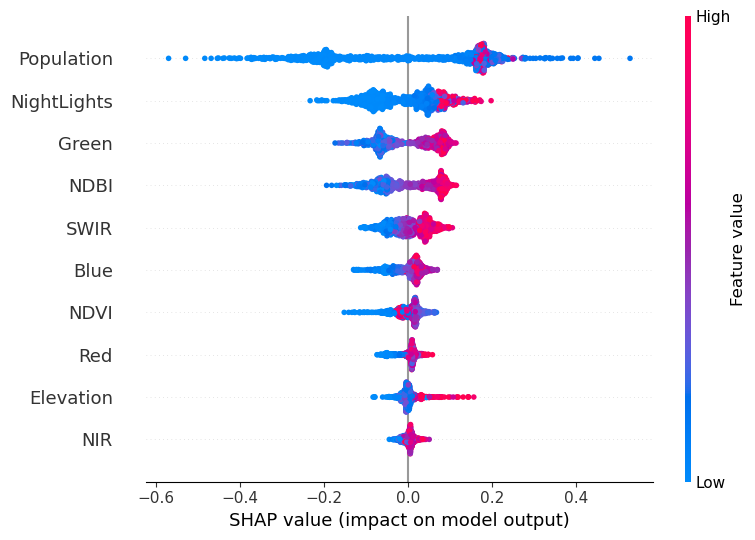

In [51]:
# ============================================================
# SHAP Beeswarm Plot
# ============================================================

shap.plots.beeswarm(
    shap_values[:, :, 1],
    show=False
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "Figure3_SHAP_Beeswarm.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

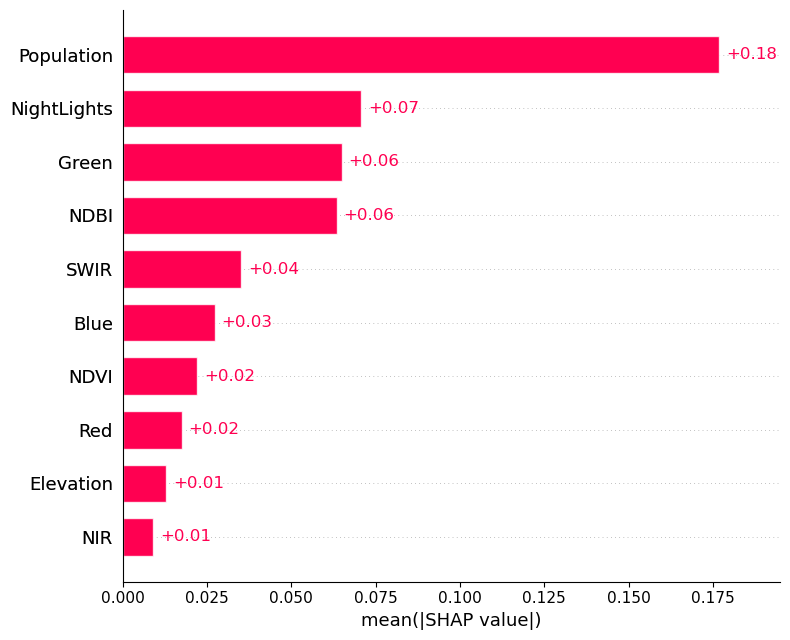

In [52]:
# ============================================================
# SHAP Global Feature Importance
# ============================================================

shap.plots.bar(
    shap_values[:, :, 1],
    show=False
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "Figure4_SHAP_Feature_Importance.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

## 4.4 SHAP Dependence Plot

The SHAP dependence plot illustrates how variations in **Night-time Lights**
influence the predicted probability of urban classification.

Each point represents an individual observation, while the vertical axis
shows the SHAP contribution of the NightLights feature to the Random Forest
prediction. This visualization helps identify non-linear relationships
between predictor values and model outputs.

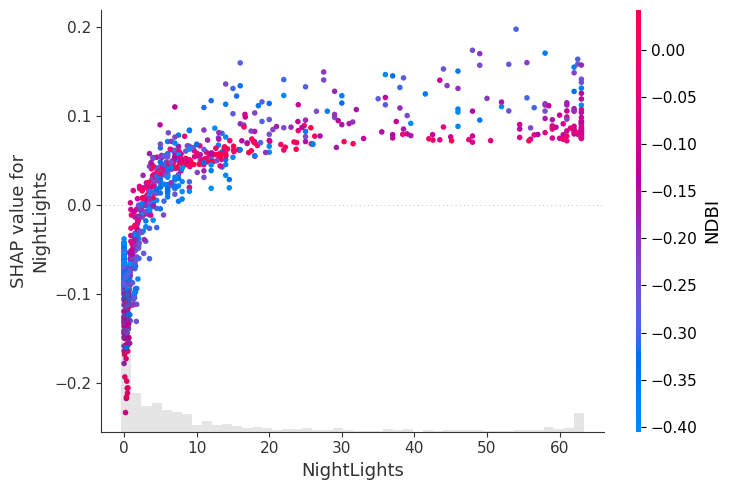

In [53]:
# ============================================================
# SHAP Dependence Plot - NightLights
# ============================================================

feature_name = "NightLights"

shap.plots.scatter(
    shap_values[:, feature_name, 1],
    color=shap_values[:, :, 1],
    show=False
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "Figure5_SHAP_Dependence_NightLights.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# PART V — Urban Probability Mapping
# ============================================================

The final urban probability map presented in the accompanying DLI 2026
paper was generated by applying the trained Random Forest classifier to a
preprocessed multi-source raster stack covering Lagos, Nigeria.

The raster preprocessing workflow (including alignment, masking,
resampling, and stacking of predictor layers) was conducted separately
prior to model inference. The resulting map is presented in the paper as
**Figure 6**.

The publication figure is included in the repository under the
`figures/` directory as:

`Figure6_Urban_Probability_2020.png`

# ============================================================
# Conclusion
# ============================================================

This notebook provides a reproducible implementation of the machine
learning workflow presented in the accompanying Deep Learning Indaba
(DLI) 2026 paper.

The workflow integrates multi-source geospatial predictors with Random
Forest, XGBoost, and a Neural Network to classify urban areas, while SHAP
is employed to provide interpretable explanations of model behaviour.

The notebook reproduces the principal analyses and figures presented in
the paper and serves as a computational companion to the published work.